# Feature engineering & Xây mô hình dự đoán

## 1. Feature engineering

Ta thực hiện các bước sau:
- Tách cột `Date` thành các cột đặc trưng của lịch: năm, tháng, ngày, tuần trong năm, thứ trong tuần.
- Đổi các cột có kiểu dữ liệu là `string` sang thành `category`, rồi mã hóa nó thành các con số.
- Bỏ bớt các cột không cần thiết: `Customers` (do rò rỉ dữ liệu), `Open` (không còn ý nghĩa do đã loại hết các hàng có giá trị `0`, chỉ còn lại các hàng có giá trị `1`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/rossmann_cleaned.csv', dtype={'StateHoliday': str}, parse_dates=['Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Store                844338 non-null  int64         
 1   DayOfWeek            844338 non-null  int64         
 2   Date                 844338 non-null  datetime64[us]
 3   Sales                844338 non-null  int64         
 4   Customers            844338 non-null  int64         
 5   Open                 844338 non-null  int64         
 6   Promo                844338 non-null  int64         
 7   StateHoliday         844338 non-null  str           
 8   SchoolHoliday        844338 non-null  int64         
 9   StoreType            844338 non-null  str           
 10  Assortment           844338 non-null  str           
 11  CompetitionDistance  844338 non-null  float64       
 12  Promo2               844338 non-null  int64         
 13  Promo2SinceWeek      8443

In [2]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

In [3]:
df['StoreType'] = df['StoreType'].astype('category').cat.codes
df['Assortment'] = df['Assortment'].astype('category').cat.codes
df['StateHoliday'] = df['StateHoliday'].astype('category').cat.codes
df['PromoInterval'] = df['PromoInterval'].astype('category').cat.codes
df.dtypes

Store                           int64
DayOfWeek                       int64
Date                   datetime64[us]
Sales                           int64
Customers                       int64
Open                            int64
Promo                           int64
StateHoliday                     int8
SchoolHoliday                   int64
StoreType                        int8
Assortment                       int8
CompetitionDistance           float64
Promo2                          int64
Promo2SinceWeek               float64
Promo2SinceYear               float64
PromoInterval                    int8
Year                            int32
Month                           int32
Day                             int32
WeekOfYear                      int64
dtype: object

In [4]:
df.drop(columns=['Customers', 'Open'], inplace=True)

In [5]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year',
       'Month', 'Day', 'WeekOfYear'],
      dtype='str')

## 2. Chia tập train/test

In [6]:
cutoff = df['Date'].max() - pd.Timedelta(weeks=6)

df_train = df[df['Date'] <= cutoff].copy()
df_test = df[df['Date'] > cutoff].copy()

print('Ngày cuối cùng trong tập train:', df_train['Date'].max())
print('Ngày đầu tiên trong tập test:', df_test['Date'].min())

Ngày cuối cùng trong tập train: 2015-06-19 00:00:00
Ngày đầu tiên trong tập test: 2015-06-20 00:00:00


In [7]:
X_train = df_train.drop(columns=['Sales', 'Date'])
y_train = df_train['Sales']

X_test = df_test.drop(columns=['Sales', 'Date'])
y_test = df_test['Sales']

In [8]:
X_train.head()

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
40282,1,5,1,0,0,2,0,1270.0,0,0.0,0.0,-1,2015,6,19,25
40283,2,5,1,0,0,0,0,570.0,1,13.0,2010.0,1,2015,6,19,25
40284,3,5,1,0,0,0,0,14130.0,1,14.0,2011.0,1,2015,6,19,25
40285,4,5,1,0,0,2,2,620.0,0,0.0,0.0,-1,2015,6,19,25
40286,5,5,1,0,0,0,0,29910.0,0,0.0,0.0,-1,2015,6,19,25


In [9]:
y_train.head()

40282    4202
40283    4926
40284    8074
40285    9686
40286    5711
Name: Sales, dtype: int64

## 3. Tính baseline

Ta cần có một baseline đơn giản để so sánh sau khi xây dựng mô hình. Baseline được chọn là **dự đoán bằng doanh thu trung bình được tính trên tổ hợp (`Store`, `DayOfWeek`, `Promo`)**, tức là đoán bằng doanh thu trung bình của cửa hàng đó theo thứ trong tuần, tính riêng cho có khuyến mãi và không có khuyến mãi.

Baseline đạt `RMSPE = 0.147`.

In [10]:
baseline = df_train.groupby(['Store', 'DayOfWeek', 'Promo'])['Sales'].mean()

In [11]:
calc_baseline = pd.merge(df_test[['Store', 'DayOfWeek', 'Promo', 'Sales']], baseline, how='left', on=['Store', 'DayOfWeek', 'Promo'], suffixes=('','_baseline'))
calc_baseline.head()

,Store,DayOfWeek,Promo,Sales,Sales_baseline
0,1,5,1,5263,5155.531250
1,2,5,1,6064,5114.769231
2,3,5,1,8314,8157.968750
3,4,5,1,13995,10194.140625
4,5,5,1,4822,5344.375000


In [12]:
calc_baseline['Sales_baseline'].isnull().sum()

np.int64(0)

In [13]:
def calc_rmspe(y_true, y_pred):
    mspe = (((y_true - y_pred)/y_true)**2).mean()
    return np.sqrt(mspe)

In [14]:
rmspe_base = calc_rmspe(calc_baseline['Sales'], calc_baseline['Sales_baseline'])
rmspe_base

np.float64(0.1467818035522821)

## 4. Huấn luyện mô hình

Mô hình mà ta chọn để dự báo cho bài toán này là XGBoost. Trước khi huấn luyện, để ý rằng metric đánh giá là Root Mean Square Percentage Error (RMSPE), tức là mô hình được đánh giá trên tỉ lệ phần trăm sai lệch. Nếu ta để nguyên dữ liệu train như vậy để huấn luyện, thì cơ chế của XGBoost sẽ tập trung tối ưu độ lớn sai lệch $|y - \hat{y}|$, chứ không để ý đến tỉ lệ sai lệch. Để mô hình huấn luyện được tối ưu cho metric RMSPE, ta nên áp dụng biến đổi log(`Sales`). 

Khi thực hiện biến đổi log(`Sales`) thì mô hình sẽ tối ưu cho phép tính $|\log(y) - \log(\hat{y})| = |\log(y/\hat{y})|$. Với sai số nhỏ thì  $\log(y/\hat{y}) \approx (y-\hat{y})/\hat{y}$ (xấp xỉ Taylor bậc nhất), mà $(y-\hat{y})/\hat{y}$ chính là sai số phần trăm.

Lưu ý, sau khi lấy log(`Sales`) ở dữ liệu trên, thì kết quả dự đoán của mô hình cần phải lấy ánh xạ ngược lại trước khi đưa vào sử dụng hay đánh giá.

In [15]:
from xgboost import XGBRegressor

y_train_log = np.log1p(y_train)

xgb = XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.1)
xgb.fit(X_train, y_train_log)

pred_log = xgb.predict(X_test)
pred = np.expm1(pred_log)

rmspe_xgb = calc_rmspe(y_test, pred)

In [16]:
rmspe_xgb

np.float64(0.1509685812200185)

**Nhận xét:** RMSPE của mô hình cho kết quả tệ hơn baseline. Kết quả này không phải thất bại, mà nó là một thông tin quý. Một mô hình thua baseline nghĩa là baseline đang nắm được thứ gì đó mà mô hình chưa học được.

**Phân tích:** Để ý rằng, baseline là một bảng tra cứu giá trị trung bình chính xác cho từng tổ hợp (`Store`, `DayOfWeek`, `Promo`). Nó "nhớ" chính xác mặt bằng doanh thu của cửa hàng số 815 vào thứ Ba có promo là bao nhiêu. Còn mô hình XGBoost nhìn `Store` dưới dạng một dãy số nguyên chạy từ `1` đến `1115`. Mô hình cây chỉ cắt ngưỡng trên dãy số đó, mà thứ tự nhãn ấy lại không có bất kỳ ý nghĩa gì (cửa hàng 815 không "lớn hơn" cửa hàng 814 về mặt ý nghĩa). Do đó, để mô hình có thể dự đoán chính xác hơn, ta sẽ thử đưa feature "mặt bằng doanh thu của cửa hàng" vào mô hình.

## 5. Cải tiến mô hình

Ta tính "mặt bằng doanh thu" của cửa hàng dựa trên dữ liệu train, rồi đưa giá trị này vào dữ liệu test để dự đoán. Cụ thể ta sẽ thêm 2 cột sau:
- `store_mean`: doanh thu trung bình của cửa hàng (tính trên tập train).
- `store_dow_mean`: doanh thu trung bình của cửa hàng theo thứ trong tuần (cũng tính trên tập train, `dow` là viết tắt của `DayOfWeek`).

Sau đó thực hiện huấn luyện và dự đoán lại.

In [17]:
s_mean = df_train.groupby('Store')['Sales'].mean()
X_train2 = pd.merge(X_train, s_mean.rename('store_mean'), how='left', on=['Store'])
X_test2 = pd.merge(X_test, s_mean.rename('store_mean'), how='left', on=['Store'])

s_mean2 = df_train.groupby(['Store', 'DayOfWeek'])['Sales'].mean()
X_train2 = pd.merge(X_train2, s_mean2.rename('store_dow_mean'), how='left', on=['Store', 'DayOfWeek'])
X_test2 = pd.merge(X_test2, s_mean2.rename('store_dow_mean'), how='left', on=['Store', 'DayOfWeek'])

X_train2.isnull().sum()

Store                  0
DayOfWeek              0
Promo                  0
StateHoliday           0
SchoolHoliday          0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
Promo2SinceWeek        0
Promo2SinceYear        0
PromoInterval          0
Year                   0
Month                  0
Day                    0
WeekOfYear             0
store_mean             0
store_dow_mean         0
dtype: int64

In [18]:
X_test2.isnull().sum()

Store                  0
DayOfWeek              0
Promo                  0
StateHoliday           0
SchoolHoliday          0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
Promo2SinceWeek        0
Promo2SinceYear        0
PromoInterval          0
Year                   0
Month                  0
Day                    0
WeekOfYear             0
store_mean             0
store_dow_mean         0
dtype: int64

In [19]:
xgb2 = XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.1)
xgb2.fit(X_train2, y_train_log)

pred_log2 = xgb2.predict(X_test2)
pred2 = np.expm1(pred_log2)

rmspe_xgb2 = calc_rmspe(y_test, pred2)

In [20]:
rmspe_xgb2

np.float64(0.1398124344706402)

**Nhận xét:** Mô hình mới đã cho kết quả tốt hơn với RMSPE = 0.140. So với RMSPE = 0.147 của baseline thì mô hình sau cải tiến đã có trung bình sai số giảm, tuy chênh lệch chưa quá lớn.

## 6. Vẽ biểu đồ phân tích và đánh giá

In [21]:
df_test['predict'] = pred2

In [22]:
def calc_mae(y_true, y_pred):
    return (np.abs(y_true - y_pred)).mean()

def calc_mape(y_true, y_pred):
    return (np.abs((y_true - y_pred)/y_true)).mean()

mae = calc_mae(df_test['Sales'], df_test['predict'])
mape = calc_mape(df_test['Sales'], df_test['predict'])

print('MAE:', mae)
print('MAPE:', mape)

MAE: 647.3196972967775
MAPE: 0.0989168100902495


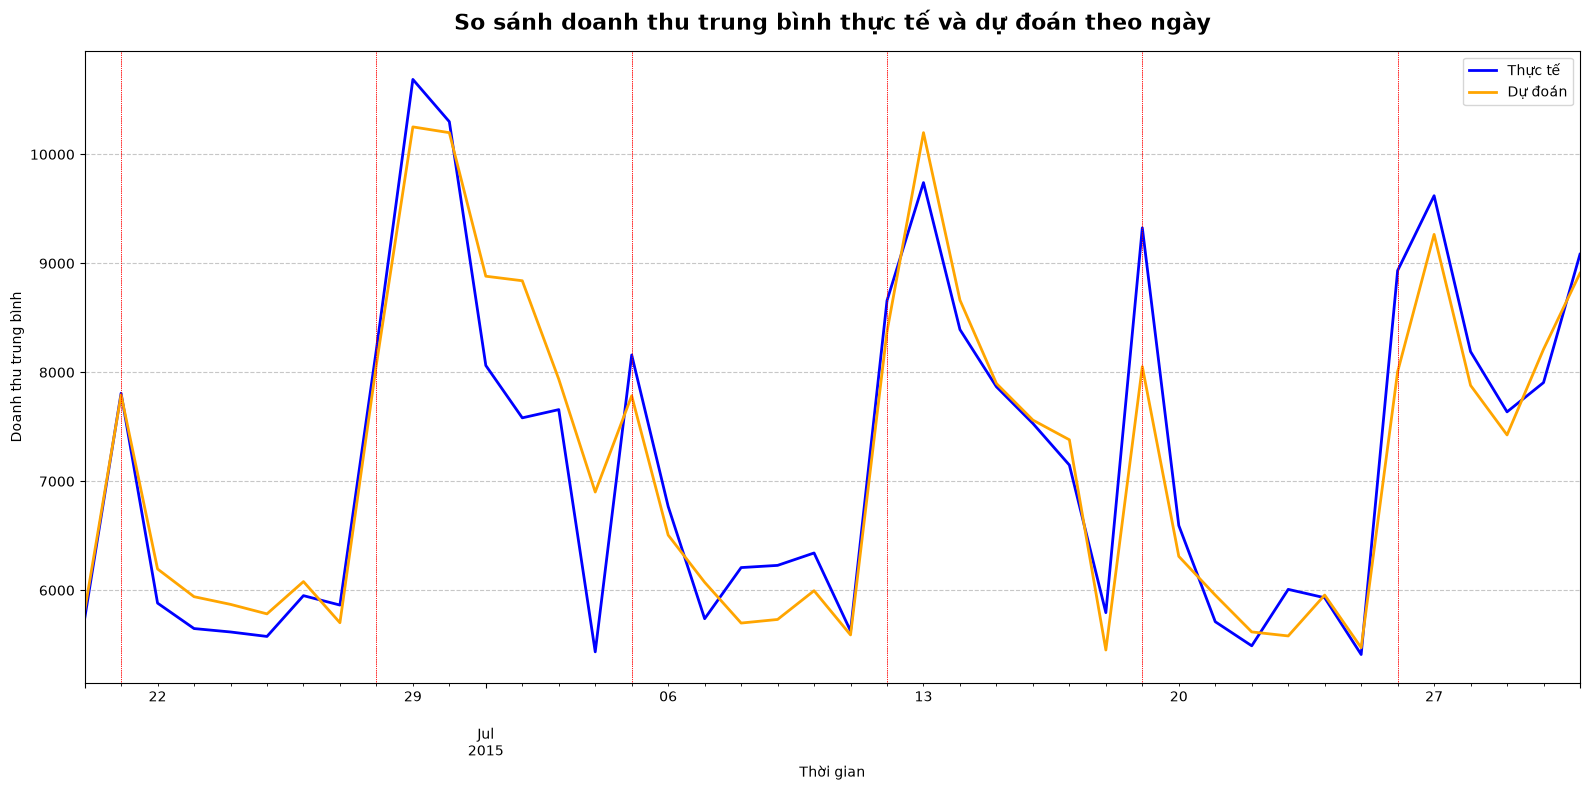

In [23]:
plt.figure(figsize=(16,8))
df_test.groupby('Date')['Sales'].mean().plot(linewidth=2, color='blue', label='Thực tế')
df_test.groupby('Date')['predict'].mean().plot(linewidth=2, color='orange', label='Dự đoán')

sundays = df_test[df_test['DayOfWeek'] == 7]['Date']

for sunday in sundays:
    plt.axvline(x=sunday, color='red', linestyle=':', alpha=0.1, linewidth=0.5)

plt.title('So sánh doanh thu trung bình thực tế và dự đoán theo ngày', fontsize=16, fontweight='bold', y=1.02)
plt.ylabel('Doanh thu trung bình')
plt.xlabel('Thời gian')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Phân phối MAPE của 1115 cửa hàng'}, ylabel='Frequency'>

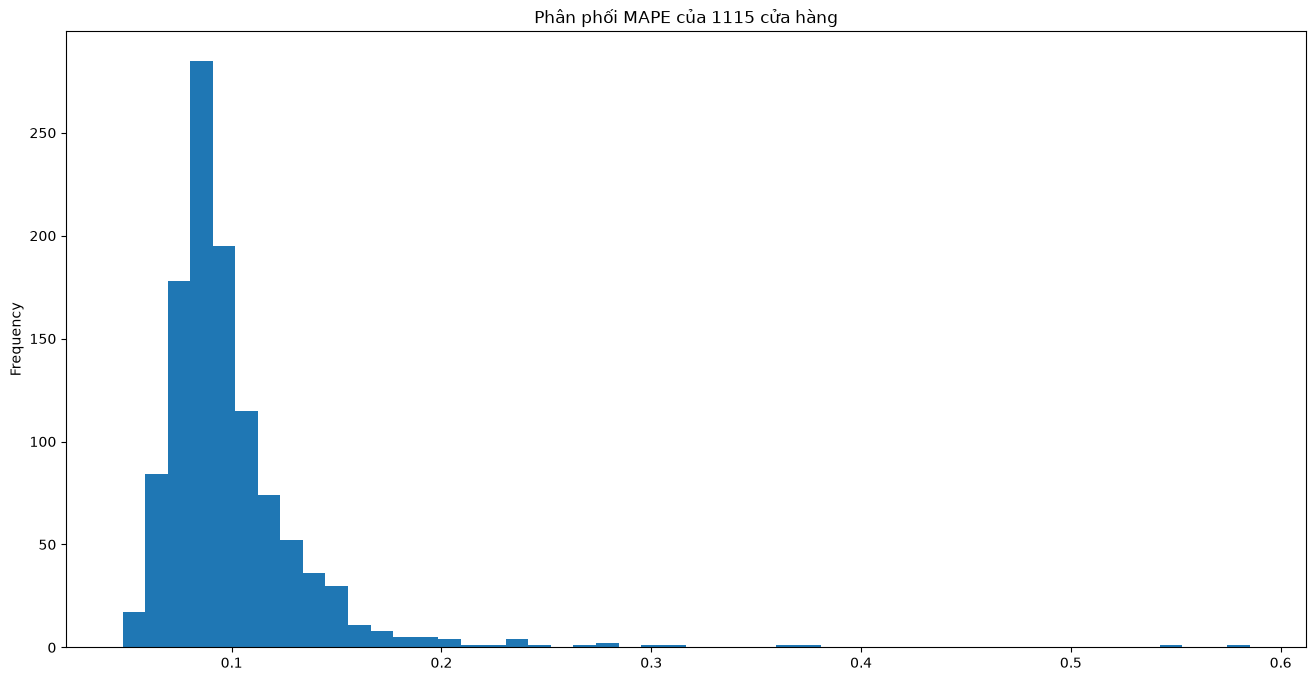

In [24]:
df_test['MAPE'] = np.abs((df_test['Sales'] - df_test['predict'])/df_test['Sales'])

mape_store = df_test.groupby('Store')['MAPE'].mean()
mape_store.plot(kind='hist', bins=50, figsize=(16,8), title='Phân phối MAPE của 1115 cửa hàng')

In [25]:
mape_store.describe()

count    1115.000000
mean        0.099376
std         0.037858
min         0.047994
25%         0.080201
50%         0.090752
75%         0.108835
max         0.585290
Name: MAPE, dtype: float64

<Axes: title={'center': 'Feature importances'}>

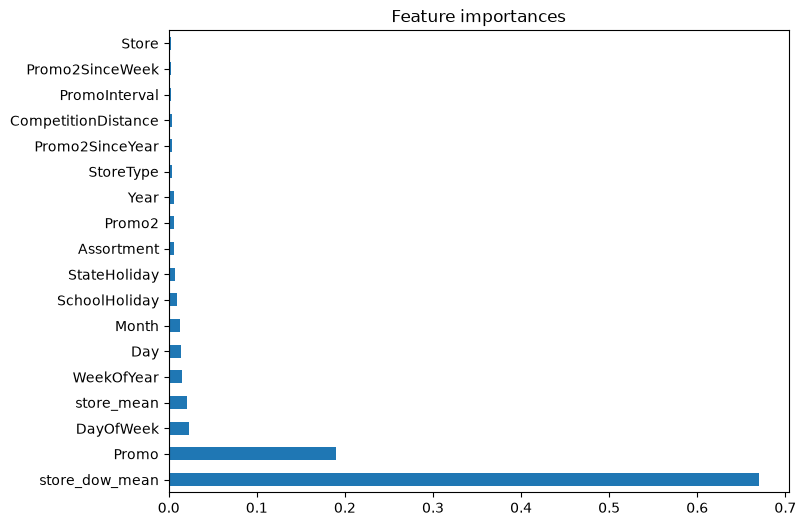

In [26]:
imp = pd.Series(xgb2.feature_importances_, index=X_train2.columns).sort_values(ascending=False)
imp.plot(kind='barh', figsize=(8,6), title='Feature importances')

**Nhận xét:**
- Đường doanh thu trung bình của dự báo bám sát đường thực tế trên suốt 6 tuần test, tái hiện đúng nhịp lên xuống của thực tế. Điều này được củng cố qua hai metric đánh giá - MAPE ~9.98% và RMSPE ~ 0.140, tức là sai số trung bình cho mỗi cửa hàng/ngày là khoảng 10%. Mô hình nắm tốt tính mùa vụ và đặc trưng riêng cho từng cửa hàng. Biểu đồ histogram về MAPE của 1115 cửa hàng cho thấy khoảng 75% cửa hàng có sai số trung bình dưới 11% và hơn 90% cửa hàng có sai số trung bình dưới 15%.
- Sai số có hai quy luật hệ thống: một là mô hình hơi hụt ở các đỉnh cao nhất (ví dụ như đỉnh cuối tháng 6, thực tế ~ 10700 nhưng dự báo ~10200), hai là bỏ lỡ vài cú sụt đột ngột (đầu tháng 7, thực tế rơi xuống ~5400 nhưng dự đoán vẫn giữ ~6900). Cả hai đều cùng một bản chất là *"mô hình dự báo **mượt** và thận trọng hơn thực tế"*. Vì feature chủ lực là doanh thu trung bình theo thứ trong lịch sử (`store_dow_mean`) nên nó bị kéo về các giá trị điển hình, khó bắt được các biến động cực đoan.
- Giả thuyết nguyên nhân cho các cú sụt đột ngột: nhiều khả năng là ngày lễ/sự kiện địa phương mà bộ đặc trưng hiện tại chưa mô tả đủ. Hướng cải thiện: bổ sung đặc trưng ngày lễ chi tiết hơn (khoảng cách tới ngày lễ, ngày trước/sau lễ), hoặc mô hình hóa cả độ biến động chứ không chỉ giá trị trung bình.